# Cari Contoh Gambar untuk Masing-Masing Fitur

Memilih 1 gambar representatif per fitur (5 fitur)

In [60]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

BASE_DIR = Path('.')
BIN_DIR = BASE_DIR / 'bin'
CSV_PATH = BASE_DIR / 'dataset' / 'dataset_crawl_070526_with_images_path.csv'

In [61]:
features = np.load(BIN_DIR / 'image_features.npy')
ids = np.load(BIN_DIR / 'image_ids.npy')
df = pd.read_csv(CSV_PATH)

id_to_meta = {}
for _, row in df.iterrows():
    wid = row['Webpage_id']
    tag = row['Tag']
    path = str(row['Screenshot_Path']).strip()
    if path:
        clean_path = path.replace('model/', '', 1)
        id_to_meta[wid] = {'tag': tag, 'path': str(BASE_DIR / clean_path)}

meta_list = []
valid = np.ones(len(ids), dtype=bool)
for i, wid in enumerate(ids):
    m = id_to_meta.get(wid)
    if m is None:
        valid[i] = False
        meta_list.append(None)
    else:
        meta_list.append(m)

features = features[valid]
meta_list = [m for m in meta_list if m is not None]
ids = ids[valid]

print(f'Total: {len(features)}, Gambling: {sum(1 for m in meta_list if m["tag"]=="gambling")}, Non: {sum(1 for m in meta_list if m["tag"]!="gambling")}')

Total: 37811, Gambling: 12503, Non: 25308


In [62]:
PATCH_DIM, EDGE_DIM, CVAR_DIM, CF_DIM, BR_DIM = 60, 3, 3, 1, 2
groups = {
    'patch':        (0, PATCH_DIM),
    'edge':         (PATCH_DIM, PATCH_DIM + EDGE_DIM),
    'color_var':    (PATCH_DIM + EDGE_DIM, PATCH_DIM + EDGE_DIM + CVAR_DIM),
    'colorfulness': (PATCH_DIM + EDGE_DIM + CVAR_DIM, PATCH_DIM + EDGE_DIM + CVAR_DIM + CF_DIM),
    'brightness':   (PATCH_DIM + EDGE_DIM + CVAR_DIM + CF_DIM, PATCH_DIM + EDGE_DIM + CVAR_DIM + CF_DIM + BR_DIM),
}

H, L = 0.80, 0.20  # high and low percentiles

def sample(group, metric='mean', tag=None, p=0.80):
    start, end = groups[group]
    g = features[:, start:end]
    if metric == 'mean':   scores = g.mean(axis=1)
    elif metric == 'col0': scores = g[:, 0]
    elif metric == 'col1': scores = g[:, 1]
    mask = np.ones(len(features), dtype=bool) if not tag else np.array([m['tag'] == tag for m in meta_list])
    fs, fi = scores[mask], np.where(mask)[0]
    best = np.argmin(np.abs(fs - np.percentile(fs, p * 100)))
    return fi[[best]], fs[[best]]

def show(idx, scores, title, label='z'):
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    m = meta_list[idx[0]]
    try:
        ax.imshow(Image.open(m['path']))
    except Exception as e:
        ax.text(0.5, 0.5, f'Err: {e}', ha='center', va='center')
    ax.set_title(f'{title} | {m["tag"]} ({label}={scores[0]:.3f})', fontsize=11)
    ax.axis('off')
    plt.tight_layout(); plt.show()

---
### 1. Brightness — bright_ratio tinggi (gambling 4.4× lebih terang)

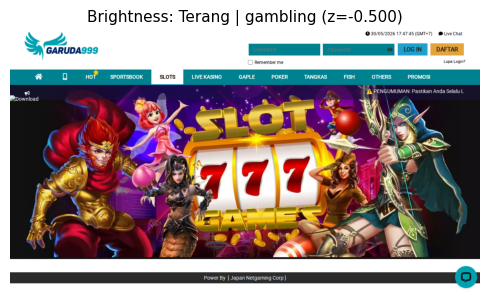

ID=150028 | screenshots/gambling/150028.png


In [63]:
i, s = sample('brightness', 'col1', 'gambling', H)
show(i, s, 'Brightness: Terang')
print(f'ID={ids[i[0]]} | {meta_list[i[0]]["path"]}')

### 2. Colorfulness — tinggi (gambling 1.6× lebih colorful)

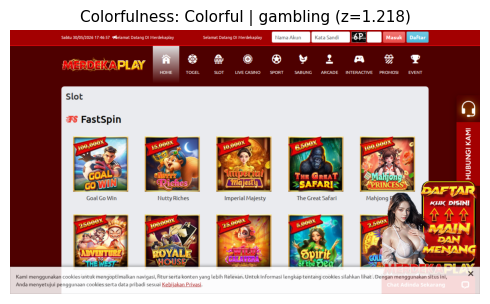

ID=149974 | screenshots/gambling/149974.png


In [64]:
i, s = sample('colorfulness', 'col0', 'gambling', H)
show(i, s, 'Colorfulness: Colorful')
print(f'ID={ids[i[0]]} | {meta_list[i[0]]["path"]}')

### 3. Edge — high density (gambling 1.3× lebih padat)

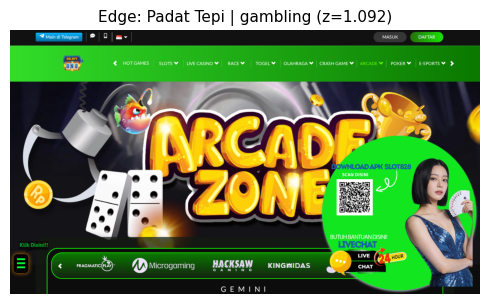

ID=175936 | screenshots/gambling/175936.png


In [65]:
i, s = sample('edge', 'mean', 'gambling', H)
show(i, s, 'Edge: Padat Tepi')
print(f'ID={ids[i[0]]} | {meta_list[i[0]]["path"]}')

### 4. Patch — rendah (berkorelasi negatif dgn gambling, r=-0.61)

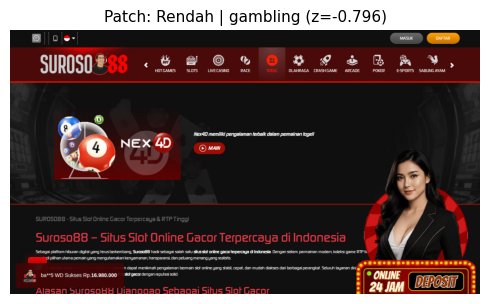

ID=136403 | screenshots/gambling/136403.png


In [66]:
i, s = sample('patch', 'mean', 'gambling', L)
show(i, s, 'Patch: Rendah')
print(f'ID={ids[i[0]]} | {meta_list[i[0]]["path"]}')

### 5. Color Variance — tinggi (non-gambling 1.3× lebih bervariasi)

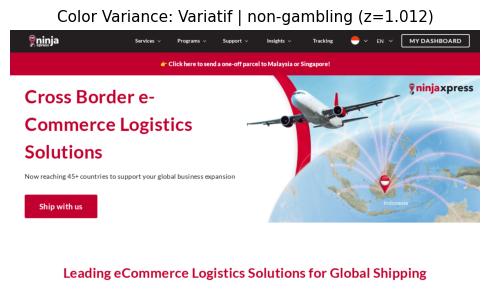

ID=80815 | screenshots/non-gambling/80815.png


In [67]:
i, s = sample('color_var', 'mean', 'non-gambling', H)
show(i, s, 'Color Variance: Variatif')
print(f'ID={ids[i[0]]} | {meta_list[i[0]]["path"]}')